# Trajectory Inference Tests

Test the new simulation-based trajectory inference for various pulse sequences.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq

import version_info as vs

## Case 1: π/2 pulse that splits arms

A single π/2 pulse at resonance should split the cloud into 50% |g⟩ (drifts) and 50% |e⟩ (gains recoil).

Case 1: 1 clouds
  Cloud 0: m=0, is_ground=True, alive=True


[Pulse(k=1, detuning_hz=0.0, phi=0.0, label='pi/2 split', rabi_frequency=111.11111111111111, duration=0.00225, beam_waist=1000000.0, probe_shift_coefficient=0.0)]

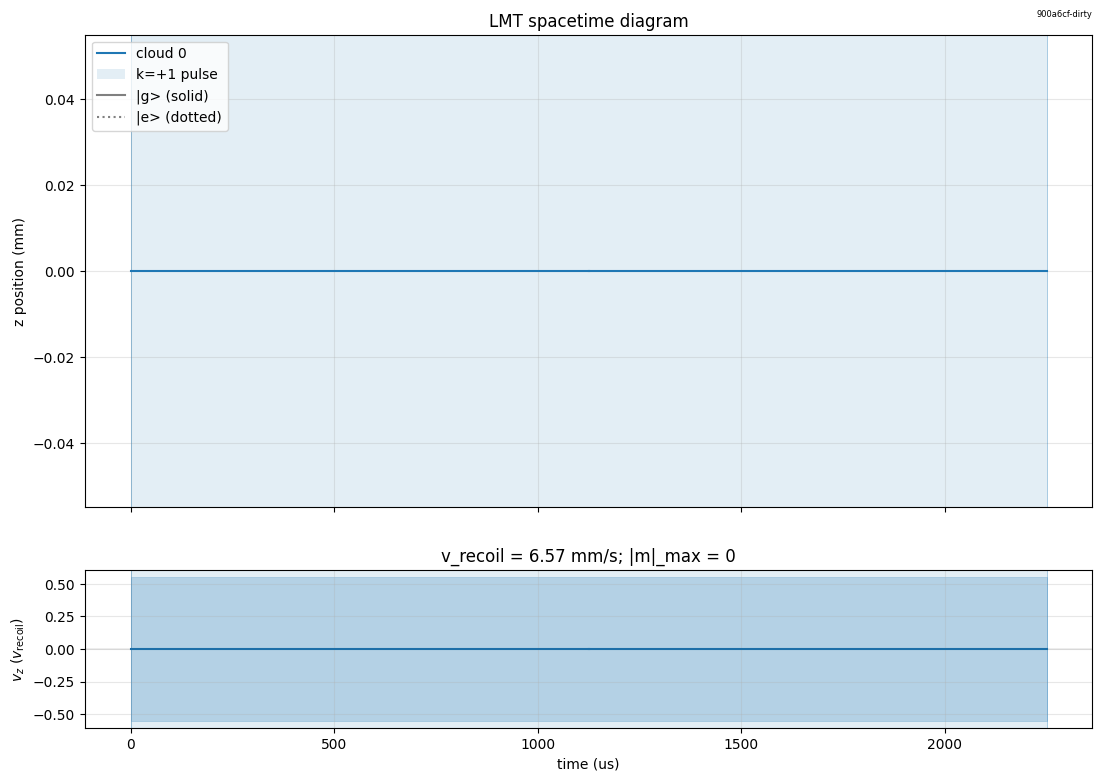

In [2]:
sequence_1 = [
    seq.Pulse(
        k=+1,
        detuning_hz=0.0,  # resonant
        phi=0.0,
        label="pi/2 split",
        rabi_frequency=sim.RABI_FREQ / 100,
        duration=sim.T_PI / 2 * 100,
    ),
]

clouds_1, ct_1 = seq.compute_spacetime_trajectory(sequence_1, plot=True)
print(f"Case 1: {len(clouds_1)} clouds")
for i, c in enumerate(clouds_1):
    print(f"  Cloud {i}: m={c.m[-1]}, is_ground={c.is_ground[-1]}, alive={c.alive}")

vs.tag_plot(small=True);

sequence_1

## Case 2: π/2 pulse, followed by LMT pulses tuned to each arm in turn

BS splits into two arms (m=0,|g⟩ and m=1,|e⟩). Then apply LMT-style pulses: first resonant with the |e⟩ arm (k=−1, detuning to match m=1), then resonant with the |g⟩ arm.

Case 2: 2 clouds
  Cloud 0: m=1, is_ground=False, alive=True
  Cloud 1: m=2, is_ground=True, alive=True


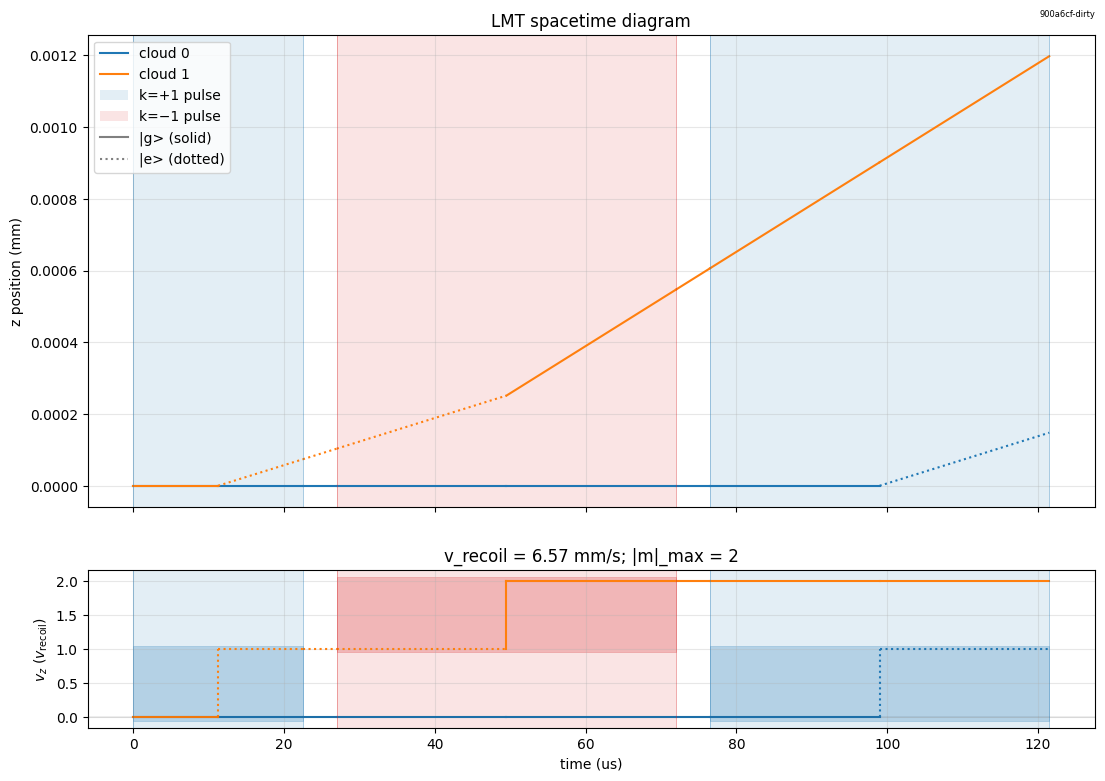

In [3]:
sequence_2 = [
    seq.Pulse(
        k=+1,
        detuning_hz=sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="BS pi/2",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI / 2,
    ),
    seq.Freefall(duration=sim.T_PI * 0.1),
    # LMT pulse resonant with m=1,|e> arm (k=-1, detuning = -3*delta_rec)
    seq.Pulse(
        k=-1,
        detuning_hz=-3 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="LMT arm1 (e,m=1)",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    ),
    seq.Freefall(duration=sim.T_PI * 0.1),
    # LMT pulse resonant with m=0,|g> arm (k=+1, detuning = +1*delta_rec)
    seq.Pulse(
        k=+1,
        detuning_hz=sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="LMT arm0 (g,m=0)",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    ),
]

clouds_2, ct_2 = seq.compute_spacetime_trajectory(sequence_2, plot=True)
print(f"Case 2: {len(clouds_2)} clouds")
for i, c in enumerate(clouds_2):
    print(f"  Cloud {i}: m={c.m[-1]}, is_ground={c.is_ground[-1]}, alive={c.alive}")

vs.tag_plot(small=True);

## Case 3: Standard Mach-Zehnder sequence

BS1 (π/2) → dark time → mirror (π) → dark time → BS2 (π/2).
Should split to 4 arms at the end.

Case 3: 4 clouds
  Cloud 0: m=1, is_ground=False, alive=True
  Cloud 1: m=0, is_ground=True, alive=True
  Cloud 2: m=0, is_ground=True, alive=True
  Cloud 3: m=1, is_ground=False, alive=True


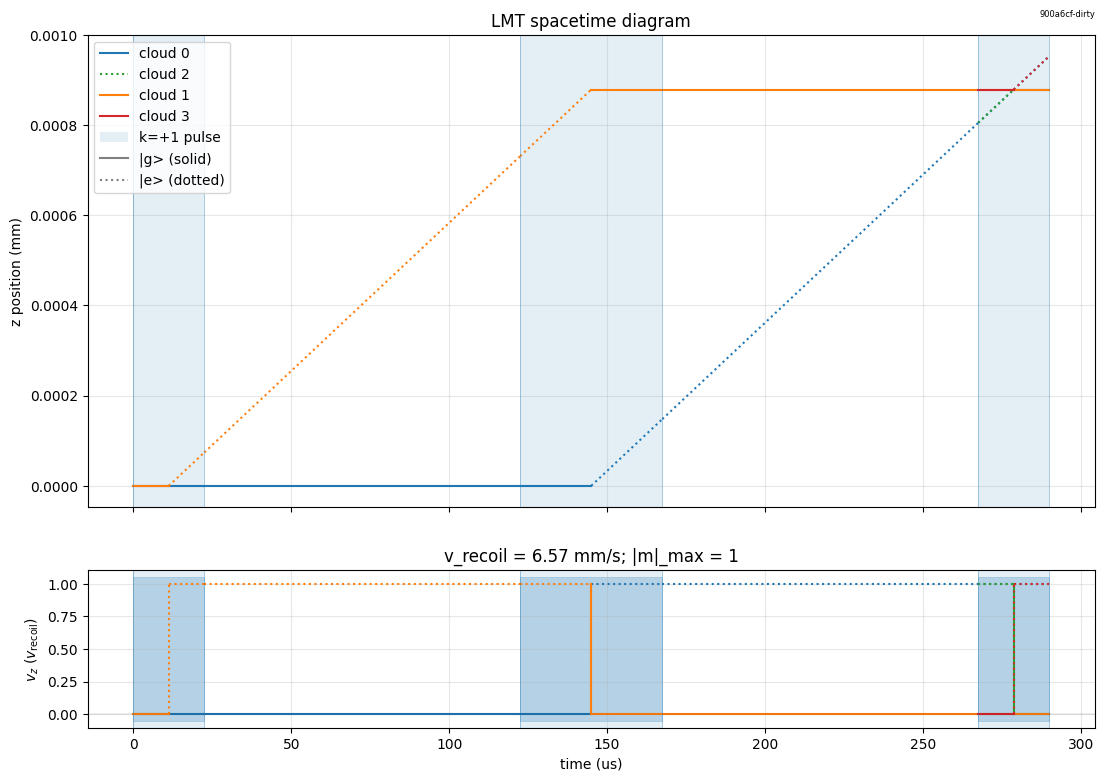

In [4]:
sequence_3 = seq.build_mach_zehnder_pulse_sequence(
    phi=0.0,
    detuning_hz=sim.RECOIL_FREQUENCY_HZ,
    time_between_pulses=100e-6,
)

clouds_3, ct_3 = seq.compute_spacetime_trajectory(sequence_3, plot=True)
print(f"Case 3: {len(clouds_3)} clouds")
for i, c in enumerate(clouds_3):
    print(f"  Cloud {i}: m={c.m[-1]}, is_ground={c.is_ground[-1]}, alive={c.alive}")

vs.tag_plot(small=True);

## Case 4: Beam splitter + π pulse to create two independent ground-state clouds, then MZ on both

1. BS1 (π/2, k=+1, on-resonance) → splits into |g,m=0⟩ and |e,m=1⟩
2. π pulse (k=+1, tuned to the |e⟩ arm) → flips |e,m=1⟩ to |g,m=2⟩ and leaves |g,m=0⟩ untouched
3. Clearout → kills |g⟩ clouds... wait, that would kill both! 

Actually the idea is: use a π pulse resonant with one arm to flip it to ground, then clearout removes the other (excited) arm. Then we have two independent ground clouds.

Let me reconsider: BS makes |g,m=0⟩ and |e,m=1⟩. Next π pulse should:
- Be off-resonance for |g,m=0⟩ (no flip)
- Be on-resonance for |e,m=1⟩ → flips to |g,m=0⟩ or |g,m=2⟩ depending on k

Actually simpler: just do π with k=+1 on-resonance for m=1. That flips the excited cloud to another ground state. Then clearout removes the original ground state.

Case 4: 3 alive out of 3 total
  Alive: 2
    Cloud 0: m=1, is_ground=False
    Cloud 1: m=3, is_ground=False
  Dead (cleared): 1
    Cloud 0: m=0, is_ground=True, cleared at step 10
  Clearouts at times (us): [373.5]


'900a6cf-dirty'

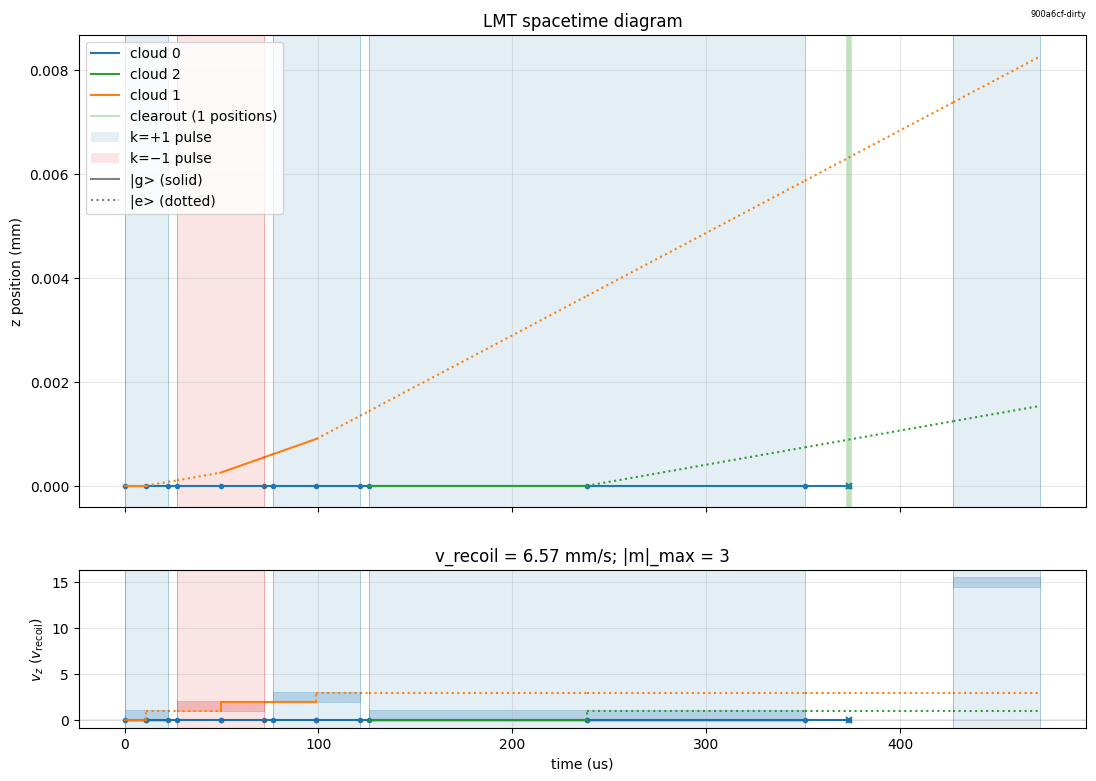

In [5]:
sequence_4 = [
    # BS1: π/2 split
    seq.Pulse(
        k=+1,
        detuning_hz=sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="BS1 pi/2",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI / 2,
    ),
    seq.Freefall(
        duration=sim.T_PI * 0.1,
    ),
    # π pulse resonant with e,m=1 (detuning=+3*delta_rec for k=+1)
    seq.Pulse(
        k=-1,
        detuning_hz=-3 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="pi on top",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    ),
    seq.Freefall(
        duration=sim.T_PI * 0.1,
    ),
    # Pi pulse for top arm
    seq.Pulse(
        k=+1,
        detuning_hz=+5 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="pi on top",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    ),
    seq.Freefall(
        duration=sim.T_PI * 0.1,
    ),
    # Pi by two for bottom arm, just so I have something to clear out
    # Make this narrow, since otherwise it hits the other arm
    seq.Pulse(
        k=+1,
        detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="pi on bottom",
        rabi_frequency=sim.RABI_FREQ / 10,
        duration=sim.T_PI / 2 * 10,
    ),
    seq.Freefall(
        duration=sim.T_PI * 0.5,
        label="freefall",
    ),
    # Clearout to remove remaining ground
    seq.Clearout(
        duration=0.0,
        label="clearout",
    ),
    # Wait for separation
    seq.Freefall(
        duration=sim.T_PI * 1.2,
        label="freefall separation",
    ),
    # Fire a pulse that's not resonant with either arm
    seq.Pulse(
        k=+1,
        detuning_hz=+30 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="off-resonant pulse",
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    ),
]

clouds_4, ct_4 = seq.compute_spacetime_trajectory(sequence_4, plot=True)
print(f"Case 4: {len(clouds_4)} alive out of {len(clouds_4)} total")
alive = [c for c in clouds_4 if c.alive]
dead = [c for c in clouds_4 if not c.alive]
print(f"  Alive: {len(alive)}")
for i, c in enumerate(alive):
    print(f"    Cloud {i}: m={c.m[-1]}, is_ground={c.is_ground[-1]}")
print(f"  Dead (cleared): {len(dead)}")
for i, c in enumerate(dead):
    print(
        f"    Cloud {i}: m={c.m[-1]}, is_ground={c.is_ground[-1]}, cleared at step {len(c.times)}"
    )
print(f"  Clearouts at times (us): {ct_4 * 1e6}")

vs.tag_plot(small=True)